In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from skimage import io, measure
import seaborn as sb
import matplotlib.pyplot as plt

import stackview
%load_ext autoreload
%autoreload 2

dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Esophagus')

In [2]:
regionlist = dirname.glob('*/*mask_cleaned.tif')
manifest = pd.DataFrame()
manifest['mask'] = list(regionlist)

manifest['name'] = manifest['mask'].apply(lambda x: x.parent.name)
manifest['dirname'] = manifest['mask'].apply(lambda x: x / f'{x.parent}')
manifest['klf4'] = manifest['dirname'].apply(lambda x: x / f'{x.name}_klf4.tif')
manifest = manifest.set_index('name')
manifest['Tissue'] = [2,1,2,2,2]

# print(region.name)
# masks = io.imread(dirname/'mask_cleaned.tif')
# klf4 = io.imread(dirname/'Klf4_combined.tif')

dx = 0.1892906
dz = 1

klf4 = {name: io.imread(row['klf4']) for name,row in manifest.iterrows()}
masks = {name: io.imread(row['mask']) for name,row in manifest.iterrows()}

manifest

,mask,dirname,klf4,Tissue
name,,,,
mTmG 1,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,2
1,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,1
mTmG 4,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,2
mTmG 3,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,2
mTmG 2,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,/Users/xies/Library/CloudStorage/OneDrive-Stan...,2


In [3]:
from skimage import filters as skfilters
from scipy.ndimage import filters

thresholded_klf4 = {}

for name,im in klf4.items():
    th = skfilters.threshold_li(im)
    im_th = im.copy().astype(float)
    im_th[im_th < th] = 0
    im_th = filters.gaussian_filter(im_th,sigma=[1,1,1])
    thresholded_klf4[name] = im_th
    io.imsave(manifest.loc[name]['dirname'] / f'{name}_manifestklf4_th.tif',thresholded_klf4[name].astype(np.uint16))
    
# stackview.slice(klf4_th,zoom_factor=0.3)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_26800/1242642199.py:10: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  im_th = filters.gaussian_filter(im_th,sigma=[1,1,1])
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Esophagus/mTmG 1/mTmG 1_manifestklf4_th.tif is a low contrast image
  return func(*args, **kwargs)
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_26800/1242642199.py:10: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  im_th = filters.gaussian_filter(im_th,sigma=[1,1,1])
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Lib

<Axes: xlabel='Cell volume', ylabel='Count'>

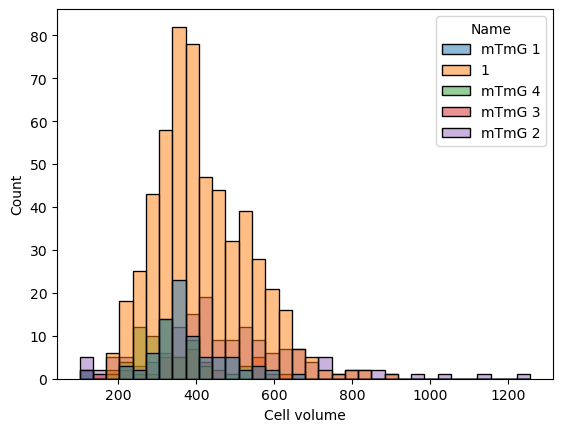

In [4]:
def basal_area(mask):
    return(mask[:3,...].sum())

def apical_area(mask):
    return(mask[-3:,...].sum())

df_regions = {}
for name in manifest.index:
    
    df = pd.DataFrame(measure.regionprops_table(masks[name],intensity_image=klf4[name],
                                                properties=['label','area','mean_intensity'],
                                               extra_properties=[basal_area,apical_area],
                                                spacing=[dz,dx,dx]))
    df = df.rename(columns={'mean_intensity':'klf4 intensity','area':'Cell volume'})
    df['basal_area'] *= dz*dx*dx
    df['apical_area'] *= dz*dx*dx
    
    df = pd.merge(df,pd.DataFrame( measure.regionprops_table(masks[name],intensity_image=thresholded_klf4[name],
                                                properties=['mean_intensity'])),left_index=True,right_index=True)
    df = df.rename(columns={'mean_intensity':'Thresholded klf4 intensity'})
    df = df[df['Cell volume'] > 100]
    df['Klf4 norm'] = df['klf4 intensity'] / df['klf4 intensity'].mean()
    df['Name'] = name
    df['Tissue'] = manifest.loc[name]['Tissue']
    df_regions[name] = df
    
    masks[name]

df_all = pd.concat(df_regions.values(),ignore_index=True)
sb.histplot(df_all,x='Cell volume',hue='Name')


526
0
99
459
828


<Axes: xlabel='Cell volume', ylabel='Count'>

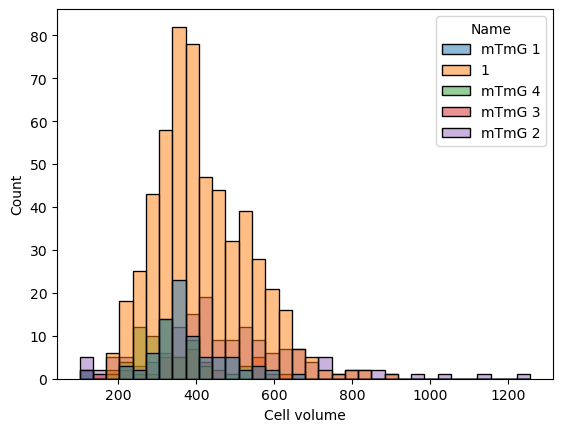

In [5]:
# Clean by by cell volume

for name in manifest.index:
    
    # Backfilter segmentation by 'valid' cells
    df = df_regions[name]
    mask = masks[name]
    valid_labels = set(df.label)
    all_labels = set(np.unique(mask)[1:])
    invalid_labels = all_labels - valid_labels
    print(len(invalid_labels))
    for l in invalid_labels:
        mask[mask == l] = 0
    masks[name] = mask

df_all = pd.concat(df_regions.values(),ignore_index=True)
sb.histplot(df_all,x='Cell volume',hue='Name')


In [6]:
from basicUtils import plot_bin_means

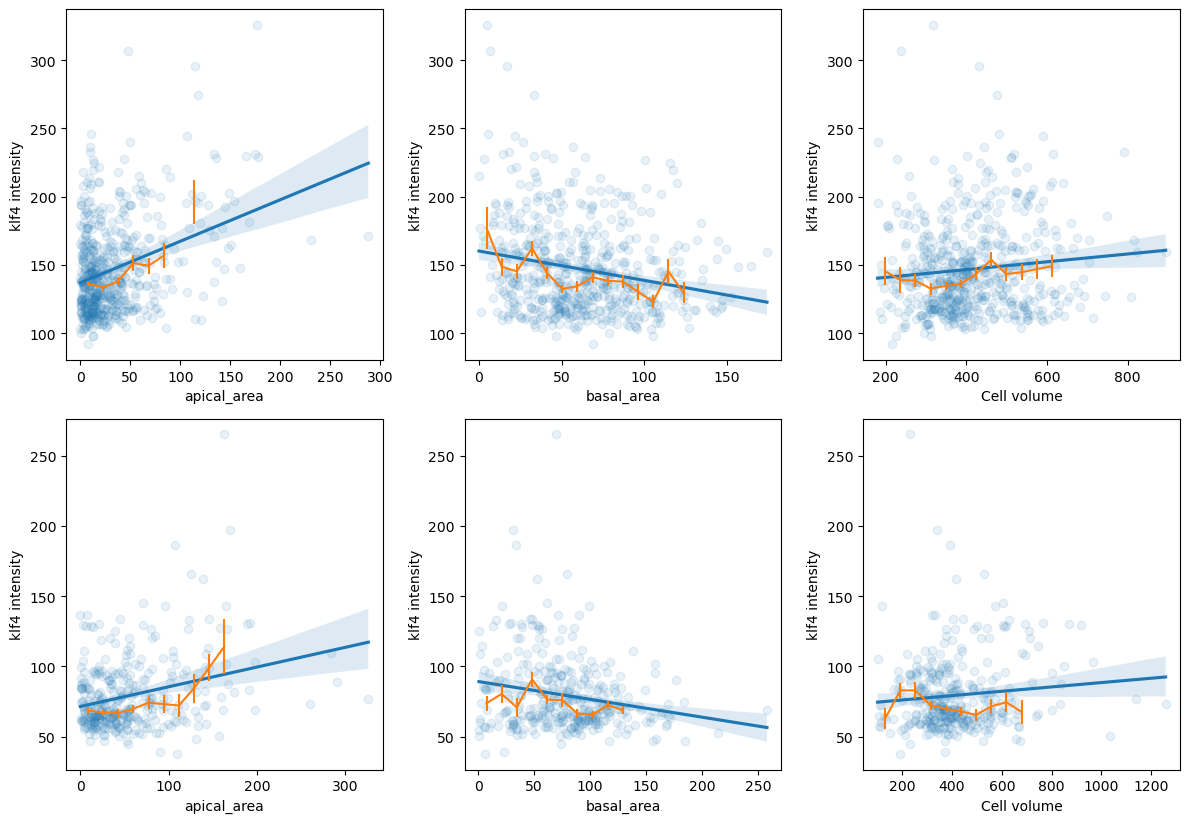

In [7]:
i = 1
plt.figure(figsize=(12,12))

for name,df in df_all.groupby('Tissue'):
    
    plt.subplot(3,3,i)
    sb.regplot(df,x='apical_area',y='klf4 intensity',scatter_kws={'alpha':0.1})
    plot_bin_means(df['apical_area'],df['klf4 intensity'],bin_edges=20)
    
    plt.subplot(3,3,i+1)
    sb.regplot(df,x='basal_area',y='klf4 intensity',scatter_kws={'alpha':0.1})
    plot_bin_means(df['basal_area'],df['klf4 intensity'],bin_edges=20)
    
    plt.subplot(3,3,i+2)
    sb.regplot(df,x='Cell volume',y='klf4 intensity',scatter_kws={'alpha':0.1})
    plot_bin_means(df['Cell volume'],df['klf4 intensity'],bin_edges=20)
    i += 3
    plt.tight_layout()

plt.savefig( manifest.iloc[0]['dirname'].parent / 'cell_shape_v_klf4.svg')

In [8]:
df_all.groupby('Tissue').count()

,label,Cell volume,klf4 intensity,basal_area,apical_area,Thresholded klf4 intensity,Klf4 norm,Name
Tissue,,,,,,,,
1,557,557,557,557,557,557,557,557
2,340,340,340,340,340,340,340,340



# SpHarm

In [9]:
from measurements import estimate_sh_coefficients

spacing = [1,0.1892906,0.1892906]
cyto_params = {}

for name in manifest.index:
    cyto_params[name] = \
        estimate_sh_coefficients(masks[name], nuc_seg=None, lmax=5, spacing = spacing, return_aligned=False)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/aicsshparam/shparam.py:134: UserWarning: Mesh centroid seems to fall outside the object. This indicates        the mesh may not be a manifold suitable for spherical harmonics        parameterization.
  warnings.warn(
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/aicsshparam/shparam.py:134: UserWarning: Mesh centroid seems to fall outside the object. This indicates        the mesh may not be a manifold suitable for spherical harmonics        parameterization.
  warnings.warn(


In [168]:
# masks[name].sum()

np.uint64(40453230)

In [10]:
for name,df in cyto_params.items():
    df['Name'] = name
df_spharm = pd.concat(cyto_params.values(),ignore_index=True)

In [119]:
# df_spharm.drop(columns='Name')

,shcoeffs_L0M0C,shcoeffs_L1M0C,shcoeffs_L1M1C,shcoeffs_L2M0C,shcoeffs_L2M1C,shcoeffs_L2M2C,shcoeffs_L3M0C,shcoeffs_L3M1C,shcoeffs_L3M2C,shcoeffs_L3M3C,...,shcoeffs_L4M1S,shcoeffs_L4M2S,shcoeffs_L4M3S,shcoeffs_L4M4S,shcoeffs_L5M1S,shcoeffs_L5M2S,shcoeffs_L5M3S,shcoeffs_L5M4S,shcoeffs_L5M5S,shcoeffs_surface_area
0,24.725211,0.336117,-1.121057,0.088071,-1.415567e+00,0.721461,1.134974,-1.582271,0.098713,1.415079,...,-4.582021e-01,0.185317,7.423519e-01,0.654087,-4.102297e-01,-1.406570e-01,-0.550004,-0.394412,-0.156294,8172.721662
1,1.589033,-0.299229,0.032075,0.371052,-1.533089e-01,-0.072736,-0.113837,-0.078378,0.012109,0.075477,...,-3.283295e-02,-0.066565,-5.042045e-02,-0.063436,-4.318203e-02,6.265044e-02,-0.022540,0.001855,-0.011296,36.590491
2,1.176083,-0.013783,-0.006342,0.346305,-1.173835e-04,-0.012681,-0.007965,0.003399,-0.000066,-0.006845,...,8.201278e-06,-0.173091,-8.824271e-05,-0.000713,-5.136840e-04,2.548281e-04,0.002978,-0.000295,-0.002671,24.070943
3,1.414879,-0.014105,-0.020236,0.416595,5.290651e-06,0.276152,-0.003118,-0.005708,-0.003646,-0.019962,...,6.847616e-07,-0.007495,6.177507e-06,-0.007217,-3.853991e-04,-2.773952e-05,-0.003197,-0.000020,-0.010357,33.180653
4,1.213553,-0.015598,-0.000637,0.434165,-1.590670e-07,-0.094332,-0.005566,-0.000136,0.000908,0.001334,...,8.135904e-08,0.001499,2.988685e-07,-0.002575,-8.442423e-07,8.986526e-07,-0.000028,0.000040,0.000063,23.835359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,5.584681,0.035795,-0.031913,-1.424796,-1.030958e-03,0.490886,-0.026659,0.032607,0.012515,0.066477,...,-2.740798e-03,0.053464,1.778436e-03,0.225995,1.840022e-02,6.806641e-04,-0.035597,0.005907,0.040553,483.392227
2146,3.007849,-0.002746,0.008211,0.130819,-4.398017e-04,0.021450,0.004007,0.009783,-0.000024,-0.177304,...,2.815114e-03,-0.080906,-2.846600e-04,0.014470,-1.260877e-02,-9.545238e-03,0.000691,0.001435,-0.024559,163.335317
2147,2.648217,-0.004581,0.084861,0.169347,3.325032e-03,0.821228,0.002276,-0.069638,0.008086,0.069051,...,3.252452e-03,-0.026143,1.728877e-04,0.145791,5.461420e-03,-1.435730e-03,-0.111749,-0.000659,-0.076410,123.453819
2148,5.243210,0.031026,0.000250,-1.256961,1.563924e-03,1.488397,-0.026131,-0.075193,0.037993,-0.056527,...,-3.308677e-04,-0.016175,5.083915e-04,0.073301,-1.999000e-02,-6.432062e-04,-0.008288,0.000845,0.043112,504.762369


In [11]:
# PCA transform

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Nuclear first

# nuc_columns = nuc_columns[df[nuc_columns].sum() > 0]
# Drop NaN columns (these are often late mitotic figures)
scaler = StandardScaler()
cyto_sph = np.array( scaler.fit_transform(df_spharm.drop(columns='Name') ) )
pca = PCA(n_components=10)
cyto_PCA = pca.fit_transform(cyto_sph)


components = pd.DataFrame(pca.components_, columns=df_spharm.drop(columns='Name').columns )

exp_var = pd.Series(pca.explained_variance_)

df_pca = pd.DataFrame(cyto_PCA,columns=[f'PC{k}' for k in range(10)])

In [12]:
# df_spharm.drop(columns='Name')

In [13]:
from visualization import plot_cells_side_by_side, reconstruct_mesh

mean_shape = df_spharm.drop(columns='Name').mean()

k = 0
max_theta = 5
min_theta = -5

reconstructed_pc_max = mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * max_theta
reconstructed_pc_min = mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * min_theta

pc0_max = {'cyto':reconstruct_mesh(reconstructed_pc_max,prefix=False)[0]}
pc0_min = {'cyto':reconstruct_mesh(reconstructed_pc_min,prefix=False)[0]}

plot_cells_side_by_side([pc0_max,pc0_min])

Widget(value='<iframe src="http://localhost:55585/index.html?ui=P_0x3630d4a40_0&reconnect=auto" class="pyvista…

In [14]:
df_merge = pd.merge(df_all,df_pca,left_index=True,right_index=True)
df_merge

,label,Cell volume,klf4 intensity,basal_area,apical_area,Thresholded klf4 intensity,Klf4 norm,Name,Tissue,PC0,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1,469.026890,63.957066,81.228721,10.928434,58.659678,0.911326,mTmG 1,2,-1.404459,2.125346,-0.224322,-1.645811,1.554200,0.511094,-0.616396,-1.265806,0.040912,-0.122937
1,7,328.211330,62.186135,104.697981,84.560998,57.233373,0.886092,mTmG 1,2,-0.953161,2.093123,0.981127,0.915454,0.858713,-0.095750,-0.679825,-0.554353,-0.815652,-0.160219
2,9,489.056381,64.227856,101.831507,15.192315,58.553025,0.915185,mTmG 1,2,0.712512,-1.920979,-1.441157,3.267849,-5.135610,0.657783,-0.104836,2.572532,-1.765603,-0.548619
3,10,379.664548,60.943469,31.172910,14.726513,55.772648,0.868385,mTmG 1,2,0.660468,1.302762,-0.133312,-0.690391,0.134356,0.606036,1.412546,0.334020,0.873126,-0.898988
4,11,348.097497,56.082141,88.144091,13.114121,50.785884,0.799116,mTmG 1,2,-0.477315,0.093751,-0.456082,0.215205,-2.973564,-0.331149,0.747241,0.854144,-0.165472,-1.137616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
892,619,361.784913,88.828365,71.446877,290.338036,81.920094,1.211692,mTmG 2,2,-1.693708,-4.771853,1.306901,0.279284,2.492475,1.599297,-1.841452,-0.379957,-0.265358,0.509307
893,629,371.100955,38.915806,23.110951,90.616425,36.601155,0.530844,mTmG 2,2,-0.179129,-3.861674,1.326056,1.379766,3.911315,1.565926,0.935198,-1.827494,0.310063,-0.434338
894,630,229.031313,88.287547,23.576753,1.899039,84.788858,1.204315,mTmG 2,2,-3.765696,-4.141173,3.795951,2.917106,-0.203630,0.167239,-2.665966,0.126368,-1.798056,0.756748
895,675,114.443994,56.723857,5.482132,42.423823,50.867714,0.773760,mTmG 2,2,-3.161598,0.952968,0.889874,-0.945101,0.354072,-1.472827,-3.648006,0.758176,-0.155857,0.443884


In [15]:
most_correlated_pcs = pd.DataFrame([np.corrcoef(df_merge['Thresholded klf4 intensity'],df_merge[f'PC{k}'])[0,1] for k in range(10)],columns=['Correlation'],index=[f'PC{k}' for k in range(10)])
most_correlated_pcs = most_correlated_pcs.sort_values(by='Correlation')
most_correlated_pcs

,Correlation
PC9,-0.106874
PC6,-0.069469
PC8,-0.037212
PC5,-0.033168
PC4,-0.017017
PC3,-0.005148
PC7,0.069476
PC1,0.073990
PC2,0.153760
PC0,0.285120


In [16]:
k = 0; l = 2;
X = np.linspace(-4,4,5)
Y = np.linspace(-4,4,5)

pca_grid = {(x,y): mean_shape + np.sqrt(exp_var.loc[k]) * components.loc[k] * x + mean_shape + np.sqrt(exp_var.loc[l]) * components.loc[l] * y
             for x in X for y in Y}
meshes = []
for i,y in enumerate(Y):
    for j,x in enumerate(X):
        meshes.append({'cyto':reconstruct_mesh(pca_grid[x,y],prefix=False)[0]})

plot_cells_side_by_side(meshes,num_cols=5)

Widget(value='<iframe src="http://localhost:55585/index.html?ui=P_0x16ae47f20_1&reconnect=auto" class="pyvista…

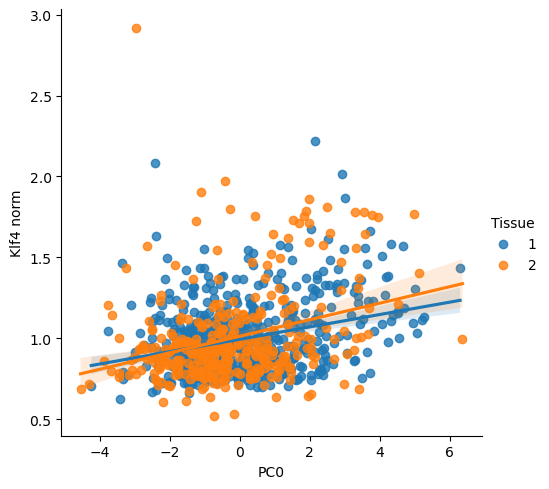

In [19]:
sb.lmplot(df_merge,x='PC0',y='Klf4 norm',hue='Tissue')

<Axes: xlabel='None-A_cut', ylabel='B_cut'>

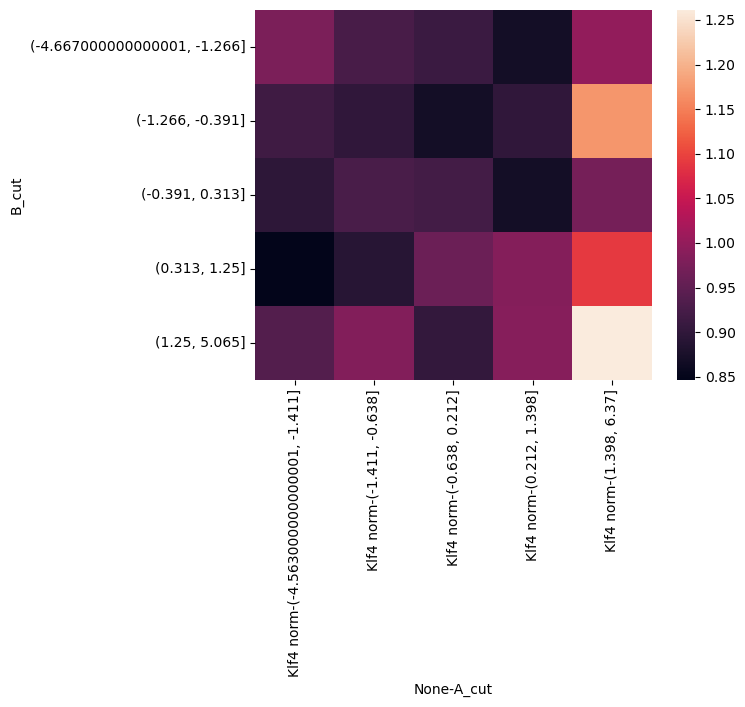

In [20]:
df_gridded = df_merge.assign(A_cut=pd.qcut(df_merge['PC0'], 5),
                             B_cut=pd.qcut(df_merge['PC2'], 5))
gridded_mean = df_gridded.groupby(['A_cut','B_cut'])['Klf4 norm'].median().reset_index()
# counts = df_gridded.groupby(['A_cut','B_cut'])['Thresholded klf4 intensity'].count().reset_index()

table = gridded_mean.pivot_table(columns='A_cut',index='B_cut')
sb.heatmap(table)

In [24]:
pca.explained_variance_ratio_

array([0.08450557, 0.06790489, 0.06115199, 0.05981693, 0.05542584,
       0.05146694, 0.04783356, 0.04336183, 0.04201885, 0.04063483])